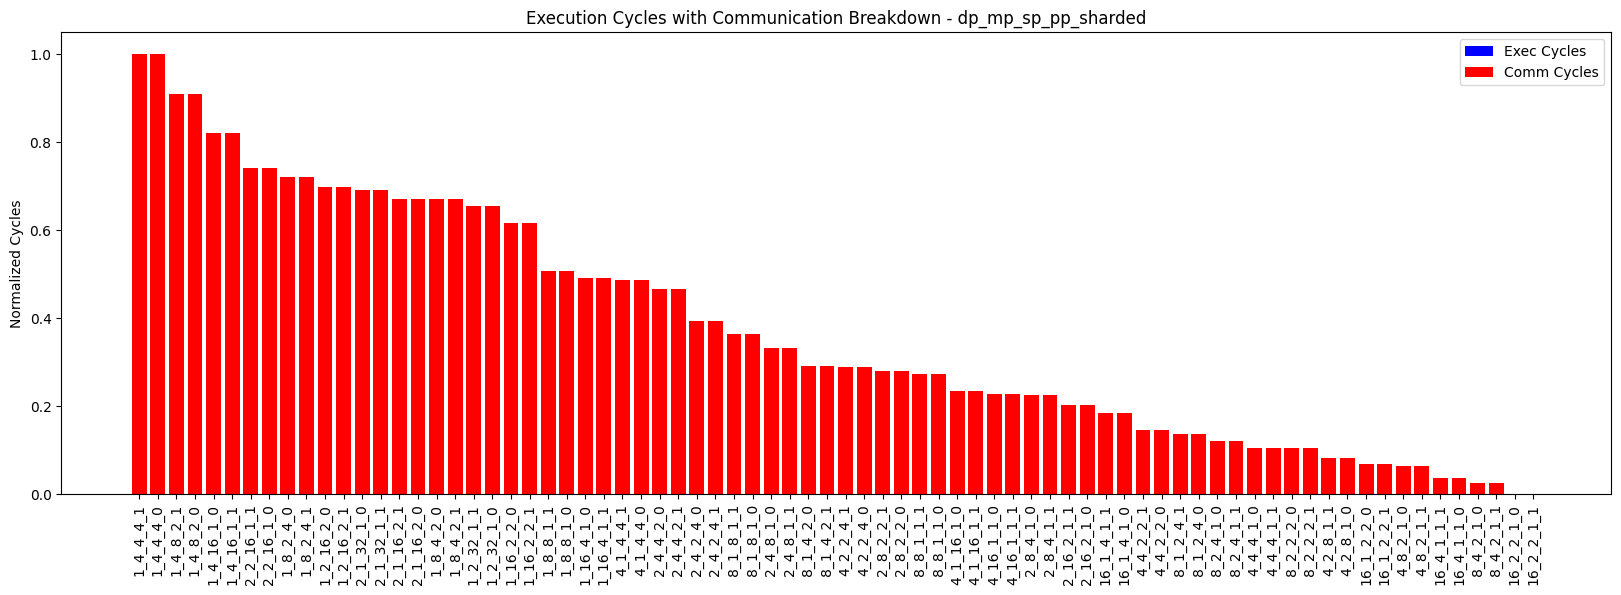

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#def plot_cycles(csv_file):
csv_file = './results/GPT3/3D_Torus.csv'
df = pd.read_csv(csv_file)
df["exec_cycles"] = df["exec_cycles"].astype(float)
df["comm_cycles"] = df["comm_cycles"].astype(float)

# Normalize values
df["exec_cycles_norm"] = (df["exec_cycles"] - df['exec_cycles'].min()) / (df['exec_cycles'].max() - df['exec_cycles'].min())
df["comm_cycles_norm"] = (df["comm_cycles"] - df['comm_cycles'].min()) / (df['comm_cycles'].max() - df['comm_cycles'].min())

#df["exec_cycles_norm"] = df["exec_cycles"] 
#df["comm_cycles_norm"] = df["comm_cycles"]

df = df.sort_values(by='exec_cycles_norm', ascending=False)
chunk_size = 100
num_chunks = (len(df) + chunk_size - 1) // chunk_size

for i in range(num_chunks):
    chunk = df.iloc[i * chunk_size:(i + 1) * chunk_size]
    
    fig, ax = plt.subplots(figsize=(20, 6))
    y_pos = np.arange(len(chunk))

    # Plot total exec_cycles as bars
    ax.bar(y_pos, chunk['exec_cycles_norm'], color='blue', label='Exec Cycles')

    # Overlay comm_cycles portion
    ax.bar(y_pos, chunk['comm_cycles_norm'], color='red', label='Comm Cycles')

    # Labels and formatting
    ax.set_xticks(y_pos)
    ax.set_xticklabels(chunk['dp_mp_sp_pp_sharded'], rotation=90)
    ax.set_ylabel('Normalized Cycles')
    ax.set_title('Execution Cycles with Communication Breakdown - dp_mp_sp_pp_sharded')
    ax.legend()

    plt.show()

# Example usage:
# plot_cycles("your_file.csv")


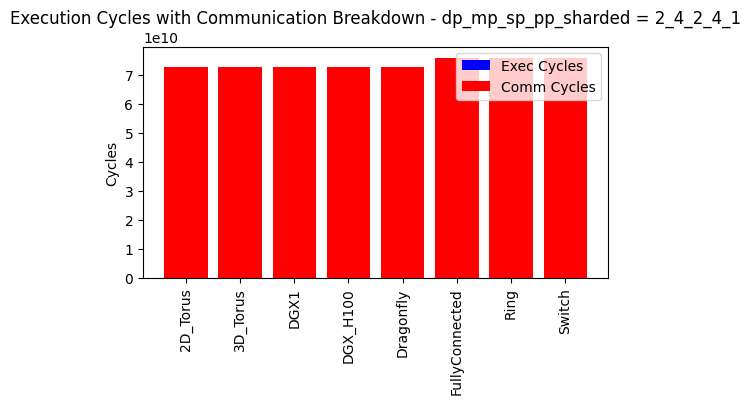

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

res_dir_path = "./results/GPT3/"
files = os.listdir(res_dir_path)

df = pd.DataFrame()
for file in files:
    if file.endswith(".csv"):
        csv_file_path = os.path.join(res_dir_path, file)
        tmp_df = pd.read_csv(csv_file_path)
        tmp_df["file"] = [file[:-4]] * len(tmp_df)
        df = pd.concat([df, tmp_df])
        
dp = 2 
mp = 4
sp = 2
pp = 4
sharded = 1
parallelism_strategy = f"{dp}_{mp}_{sp}_{pp}_{sharded}"
df_to_plot = df[df["dp_mp_sp_pp_sharded"] == parallelism_strategy]



df_to_plot.loc[:, "exec_cycles"] = df_to_plot["exec_cycles"].astype(float)
df_to_plot.loc[:, "comm_cycles"] = df_to_plot["comm_cycles"].astype(float)


df_to_plot = df_to_plot.sort_values(by='file')

fig, ax = plt.subplots(figsize=(6, 3))
y_pos = np.arange(len(df_to_plot))

# Plot total exec_cycles as bars
ax.bar(y_pos, df_to_plot['exec_cycles'], color='blue', label='Exec Cycles')

# Overlay comm_cycles portion
ax.bar(y_pos, df_to_plot['comm_cycles'], color='red', label='Comm Cycles')

# Labels and formatting
ax.set_xticks(y_pos)
ax.set_xticklabels(df_to_plot['file'], rotation=90)
ax.set_ylabel('Cycles')
ax.set_title(f"Execution Cycles with Communication Breakdown - dp_mp_sp_pp_sharded = {parallelism_strategy}")
ax.legend()

plt.show()